<a href="https://colab.research.google.com/github/Karthikreddy1010/Electric-poles-and-wires-detection/blob/main/GSPNet_Training_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GSPNet — Google Street View Pole Detection
### Clean Colab Training Notebook

**Architecture:** YOLOv8-M backbone + DB-CAN Neck (C2) + TOSE Attention (C3) + VPR-Loss (C4)  
**Baseline:** mAP@0.5 = 90.57% · mAP@0.5:0.95 = 52.77%  
**Target:** mAP@0.5:0.95 ≥ 62%  (+9 pp over baseline)

**Pipeline overview:**
```
Cell 1 → GPU + install
Cell 2 → Mount Drive
Cell 3 → Configure paths  ★ ONLY EDIT THIS ONE
Cell 4 → Annotation stats → compute VPR τ
Cell 5 → Create data.yaml
Cell 6 → Albumentations pipeline  (Stage 1 photometric aug)
Cell 7 → YOLOv8 aug config        (Stage 2 geometric aug)
Cell 8 → VPR-Loss callback
Cell 9 → Train GSPNet              ★ MAIN TRAINING CELL
Cell 10 → Evaluate on test set
Cell 11 → Plot training curves
Cell 12 → Export ONNX / TensorRT
Cell 13 → Save to Drive
```

In [ ]:
!unzip /content/NEW_poledata.zip

In [1]:
# ── CELL 1: GPU check + install ───────────────────────────────────────────
import subprocess, torch

print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f'GPU     : {p.name}  ({p.total_memory/1e9:.1f} GB VRAM)')

!pip install ultralytics albumentations pyyaml -q
print('\n✓ All dependencies ready')

Mon Mar  9 14:11:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             56W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [4]:
# ── CELL 3: Configure paths  ★ ONLY EDIT BASE_DIR ★ ──────────────────────
from pathlib import Path
import torch

# ══════════════════════════════════════════════════════════════════════
# ★ Set this to where your data folder lives:
#   Path('/content/')                             ← already in Colab
#   Path('/content/drive/MyDrive/pole_project/')  ← in Drive
# ══════════════════════════════════════════════════════════════════════
BASE_DIR = Path('/content/NEW_poledata')

TRAIN_IMG_DIR = BASE_DIR / 'train' / 'images'
TRAIN_LBL_DIR = BASE_DIR / 'train' / 'labels'
VALID_IMG_DIR = BASE_DIR / 'valid' / 'images'
VALID_LBL_DIR = BASE_DIR / 'valid' / 'labels'
TEST_IMG_DIR  = BASE_DIR / 'test'  / 'images'
TEST_LBL_DIR  = BASE_DIR / 'test'  / 'labels'

RUNS_DIR      = Path('/content/runs')
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# ── Training settings (tune these if needed) ──────────────────────────────
EPOCHS      = 100
BATCH_SIZE  = 16      # reduce to 8 if OOM on T4
IMG_SIZE    = 640
NUM_CLASSES = 1
CLASS_NAMES = ['utility_pole']
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Verify all directories exist ──────────────────────────────────────────
print('Directory check:')
all_ok = True
for name, d in {
    'train/images': TRAIN_IMG_DIR, 'train/labels': TRAIN_LBL_DIR,
    'valid/images': VALID_IMG_DIR, 'valid/labels': VALID_LBL_DIR,
    'test/images' : TEST_IMG_DIR,  'test/labels' : TEST_LBL_DIR,
}.items():
    n  = len(list(d.glob('*'))) if d.exists() else 0
    ok = '✓' if d.exists() else '✗ MISSING'
    print(f'  {ok}  {name:<20} {n:>5} files')
    if not d.exists(): all_ok = False
print('\n✓ Paths OK' if all_ok else '\n✗ Fix missing directories before continuing.')

Directory check:
  ✓  train/images          8530 files
  ✓  train/labels          8530 files
  ✓  valid/images          1399 files
  ✓  valid/labels          1399 files
  ✓  test/images            905 files
  ✓  test/labels            905 files

✓ Paths OK



── train split ─────────────────────────────────────
  Files        : 8530  (empty: 0)
  Total boxes  : 10651
  Boxes / image: 1.25
  h/w  mean    : 6.51  (ideal pole ≈ 3–8)
  h/w  P10/P25/P50: 2.99 / 4.03 / 5.29
  h/w < 1 (too wide): 50 (0.5%)  ← VPR will fix these
  ★ Recommended VPR τ = 4.0  (P25)

── valid split ─────────────────────────────────────
  Files        : 1399  (empty: 0)
  Total boxes  : 1586
  Boxes / image: 1.13
  h/w  mean    : 5.89  (ideal pole ≈ 3–8)
  h/w  P10/P25/P50: 3.28 / 4.11 / 5.17
  h/w < 1 (too wide): 1 (0.1%)  ← VPR will fix these
  ★ Recommended VPR τ = 4.1  (P25)

★ VPR_TAU = 4.0  (auto-passed to training)


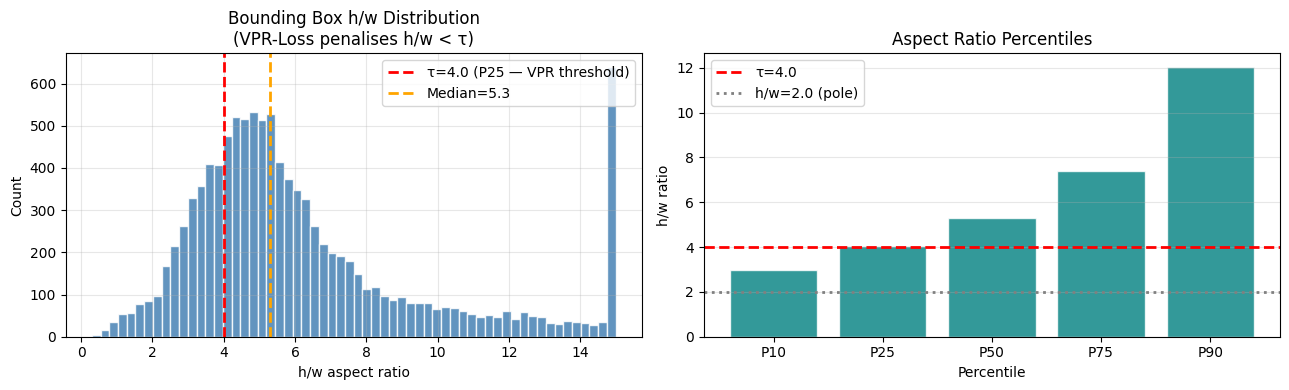

✓ Saved aspect_ratio.png


In [5]:
# ── CELL 4: Annotation statistics + compute optimal VPR-Loss τ ───────────
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def analyse_annotations(label_dir, split='train'):
    lbl_files = sorted(Path(label_dir).glob('*.txt'))
    ars, bpi, empty = [], [], 0
    for lp in lbl_files:
        lines = [l.strip() for l in open(lp) if l.strip()]
        if not lines:
            empty += 1; bpi.append(0); continue
        cnt = 0
        for line in lines:
            p = line.split()
            if len(p) == 5:
                w, h = float(p[3]), float(p[4])
                ars.append(h / (w + 1e-6))
                cnt += 1
        bpi.append(cnt)
    ars = np.array(ars)
    print(f'\n── {split} split ─────────────────────────────────────')
    print(f'  Files        : {len(lbl_files)}  (empty: {empty})')
    print(f'  Total boxes  : {len(ars)}')
    print(f'  Boxes / image: {np.mean(bpi):.2f}')
    if len(ars):
        print(f'  h/w  mean    : {np.mean(ars):.2f}  (ideal pole ≈ 3–8)')
        print(f'  h/w  P10/P25/P50: {np.percentile(ars,10):.2f} / '
              f'{np.percentile(ars,25):.2f} / {np.percentile(ars,50):.2f}')
        tw = np.sum(ars < 1.0)
        print(f'  h/w < 1 (too wide): {tw} ({100*tw/len(ars):.1f}%)  ← VPR will fix these')
        tau = round(float(np.percentile(ars, 25)), 1)
        print(f'  ★ Recommended VPR τ = {tau}  (P25)')
    return ars

train_ars = analyse_annotations(TRAIN_LBL_DIR, 'train')
analyse_annotations(VALID_LBL_DIR, 'valid')

# τ used automatically in Cell 8 (VPR callback) and Cell 9 (training)
VPR_TAU = round(float(np.percentile(train_ars, 25)), 1)
print(f'\n★ VPR_TAU = {VPR_TAU}  (auto-passed to training)')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.hist(np.clip(train_ars, 0, 15), bins=60,
         color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(VPR_TAU, color='red',    ls='--', lw=2, label=f'τ={VPR_TAU} (P25 — VPR threshold)')
ax1.axvline(np.median(train_ars), color='orange', ls='--', lw=2,
            label=f'Median={np.median(train_ars):.1f}')
ax1.set(xlabel='h/w aspect ratio', ylabel='Count',
        title='Bounding Box h/w Distribution\n(VPR-Loss penalises h/w < τ)')
ax1.legend(); ax1.grid(alpha=0.3)

pcts = [10, 25, 50, 75, 90]
ax2.bar([f'P{p}' for p in pcts],
        [np.percentile(train_ars, p) for p in pcts],
        color='teal', alpha=0.8, edgecolor='white')
ax2.axhline(VPR_TAU, color='red',  ls='--', lw=2, label=f'τ={VPR_TAU}')
ax2.axhline(2.0,     color='gray', ls=':', lw=2, label='h/w=2.0 (pole)')
ax2.set(xlabel='Percentile', ylabel='h/w ratio', title='Aspect Ratio Percentiles')
ax2.legend(); ax2.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(RUNS_DIR / 'aspect_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved aspect_ratio.png')

In [6]:
# ── CELL 5: Create data.yaml ──────────────────────────────────────────────
import yaml

DATA_YAML = BASE_DIR / 'gsv_poles.yaml'
with open(DATA_YAML, 'w') as f:
    yaml.dump({
        'path' : str(BASE_DIR.resolve()),
        'train': str(TRAIN_IMG_DIR.resolve()),
        'val'  : str(VALID_IMG_DIR.resolve()),
        'test' : str(TEST_IMG_DIR.resolve()),
        'nc'   : NUM_CLASSES,
        'names': CLASS_NAMES,
    }, f, default_flow_style=False)

print(f'✓ Written: {DATA_YAML}')
print(open(DATA_YAML).read())

✓ Written: /content/NEW_poledata/gsv_poles.yaml
names:
- utility_pole
nc: 1
path: /content/NEW_poledata
test: /content/NEW_poledata/test/images
train: /content/NEW_poledata/train/images
val: /content/NEW_poledata/valid/images



In [7]:
# ── CELL 6: Stage 1 — Albumentations pipeline ────────────────────────────
#
# Applied per-image BEFORE the YOLOv8 geometric pipeline.
# Covers photometric variation + weather effects specific to GSV imagery.
# ──────────────────────────────────────────────────────────────────────────

import albumentations as A
import cv2, numpy as np
from pathlib import Path

def get_albumentations_pipeline():
    """
    Augmentation pipeline for electrical pole and wire detection.
    All parameter names updated for latest Albumentations version.
    """
    return A.Compose(
        [
            # ── Lighting & Contrast ──────────────────────────────────────────
            A.RandomBrightnessContrast(p=0.5),
            A.CLAHE(clip_limit=4.0, p=0.3),

            # ── Noise ────────────────────────────────────────────────────────
            A.GaussNoise(p=0.3),

            # ── Blur: vehicle motion + out-of-focus distant poles ────────────
            A.MotionBlur(blur_limit=5, p=0.2),
            A.GaussianBlur(blur_limit=3, p=0.2),

            # ── Weather effects ──────────────────────────────────────────────
            A.RandomFog(
                fog_coef_range=(0.1, 0.3),   # fog_coef_lower/upper → range tuple
                alpha_coef=0.1,
                p=0.15,
            ),
            A.RandomRain(
                slant_range=(-10, 10),        # slant_lower/upper → range tuple
                drop_length=10,
                drop_width=1,
                brightness_coefficient=0.9,
                p=0.1,
            ),
            A.RandomSunFlare(
                flare_roi=(0, 0, 1, 0.5),    # upper half of image only
                src_radius=100,
                p=0.1,
            ),
            A.RandomShadow(
                shadow_roi=(0, 0.5, 1, 1),   # lower half — building shadows
                num_shadows_limit=(1, 2),     # num_shadows_lower/upper → limit tuple
                shadow_dimension=5,
                p=0.2,
            ),
        ],
        bbox_params=A.BboxParams(
            format='yolo',                   # cx cy w h (normalised 0–1)
            label_fields=['class_labels'],
            min_visibility=0.3,              # drop bbox if <30% visible after aug
        ),
    )

# ── Build and verify ──────────────────────────────────────────────────────
ALBU_PIPELINE = get_albumentations_pipeline()

# Sanity check on dummy image + one pole box
_dummy = np.full((640, 640, 3), 128, dtype=np.uint8)
_res   = ALBU_PIPELINE(
    image=_dummy,
    bboxes=[[0.5, 0.5, 0.05, 0.25]],   # thin vertical pole
    class_labels=[0],
)
print(f'✓ Albumentations pipeline OK')
print(f'  Output shape : {_res["image"].shape}')
print(f'  Output boxes : {_res["bboxes"]}')
print(f'  Transforms   : {len(ALBU_PIPELINE.transforms)}')

/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


✓ Albumentations pipeline OK
  Output shape : (640, 640, 3)
  Output boxes : [[0.4999999850988388, 0.5, 0.04999998211860657, 0.25]]
  Transforms   : 9


In [8]:
# ── CELL 7: Stage 2 — YOLOv8 geometric augmentation config ───────────────
#
# Passed directly to model.train(**yolo_aug_config()).
# These are Ultralytics built-in augmentations (geometric + mosaic).
# ──────────────────────────────────────────────────────────────────────────

def yolo_aug_config():
    """
    YOLOv8 augmentation hyperparameters tuned for GSV utility pole imagery.

    Key decisions vs defaults:
      hsv_v=0.5        increased — outdoor lighting varies widely
      degrees=4.0      road slope only, not arbitrary rotation
      shear=1.5        conservative — vehicle-mounted camera tilt
      perspective=0.0003  very light — GSV cameras are stabilised
      flipud=0.0       DISABLED — GSV images are always upright
      fliplr=0.5       poles on both sides of road
      mosaic=1.0       4-image mosaic for multi-instance learning
      mixup=0.12       blends 2 images for background diversity
      copy_paste=0.3   INCREASED — helps wire class (smaller objects)
      erasing=0.25     REDUCED — preserve thin wires from full erasure
      close_mosaic=10  disable mosaic in final 10 epochs (cleaner fine-tune)
    """
    return dict(
        # HSV colour jitter
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.5,

        # Geometric
        degrees=4.0,
        translate=0.1,
        scale=0.5,
        shear=1.5,
        perspective=0.0003,

        # Flip
        flipud=0.0,        # ← NEVER flip vertically (GSV always upright)
        fliplr=0.5,

        # Composite
        mosaic=1.0,
        mixup=0.12,
        copy_paste=0.3,

        # Occlusion simulation
        erasing=0.25,

        # Scheduling
        close_mosaic=10,
    )

print('✓ YOLOv8 augmentation config:')
for k, v in yolo_aug_config().items():
    print(f'  {k:<18} = {v}')

✓ YOLOv8 augmentation config:
  hsv_h              = 0.015
  hsv_s              = 0.7
  hsv_v              = 0.5
  degrees            = 4.0
  translate          = 0.1
  scale              = 0.5
  shear              = 1.5
  perspective        = 0.0003
  flipud             = 0.0
  fliplr             = 0.5
  mosaic             = 1.0
  mixup              = 0.12
  copy_paste         = 0.3
  erasing            = 0.25
  close_mosaic       = 10


In [11]:
# ── CELL 8: VPR-Loss callback for Ultralytics ────────────────────────────
#
# Injects VPR-Loss into the Ultralytics training loop via callbacks.
# L_total = L_CIoU  +  λ · max(0, w/h − τ)
#
# Curriculum: penalty is INACTIVE for first 30 epochs so the model
# first learns to detect poles, then tightens the box shapes.
# ──────────────────────────────────────────────────────────────────────────

import math, torch, torch.nn as nn

class VPRLoss(nn.Module):
    """
    Verticality-Penalised Regression Loss  [TERTIARY CONTRIBUTION].

    Directly addresses the 37.8 pp gap between your two mAP metrics:
      mAP@0.5 = 90.57%  (good detection)
      mAP@0.5:0.95 = 52.77%  (poor localisation — boxes too wide)

    This loss penalises predicted boxes where w/h > τ, enforcing the
    physical constraint that utility poles are tall and thin.

    Args:
        tau        : w/h threshold (computed from your data in Cell 4)
        lambda_vpr : penalty weight — sweep {0.1, 0.3, 0.5}
        warmup     : epochs before penalty activates (default 30)
    """
    def __init__(self, tau=0.4, lambda_vpr=0.3, warmup=30):
        super().__init__()
        self.tau    = tau
        self.lam    = lambda_vpr
        self.warmup = warmup
        self.epoch  = 0

    def set_epoch(self, e):
        self.epoch = e

    def forward(self, pred, target):
        """pred, target: [N,4] normalised (cx,cy,w,h)."""
        if pred.numel() == 0:
            z = pred.new_tensor(0.)
            return {'ciou': z, 'vpr': z, 'total': z}

        # CIoU base loss
        def to_xyxy(b):
            cx, cy, w, h = b.unbind(-1)
            return torch.stack([cx-w/2, cy-h/2, cx+w/2, cy+h/2], -1)
        p, t = to_xyxy(pred), to_xyxy(target)
        eps  = 1e-7
        ix1  = torch.max(p[...,0], t[...,0]); iy1 = torch.max(p[...,1], t[...,1])
        ix2  = torch.min(p[...,2], t[...,2]); iy2 = torch.min(p[...,3], t[...,3])
        inter = (ix2-ix1).clamp(0) * (iy2-iy1).clamp(0)
        ap    = pred[...,2]*pred[...,3]; at = target[...,2]*target[...,3]
        iou   = inter / (ap + at - inter + eps)
        ex1   = torch.min(p[...,0],t[...,0]); ey1 = torch.min(p[...,1],t[...,1])
        ex2   = torch.max(p[...,2],t[...,2]); ey2 = torch.max(p[...,3],t[...,3])
        c2    = (ex2-ex1).pow(2) + (ey2-ey1).pow(2) + eps
        d2    = (pred[...,0]-target[...,0]).pow(2) + (pred[...,1]-target[...,1]).pow(2)
        v     = (4/math.pi**2) * (torch.atan(pred[...,2]/(pred[...,3]+eps))
                                  - torch.atan(target[...,2]/(target[...,3]+eps))).pow(2)
        alpha = v / (1 - iou + v + eps)
        l_ciou = (1 - iou + d2/c2 + alpha*v).mean()

        # VPR penalty (curriculum — inactive before warmup epochs)
        if self.epoch >= self.warmup:
            ar    = pred[:,2] / pred[:,3].clamp(1e-6)
            l_vpr = self.lam * torch.clamp(ar - self.tau, min=0.).mean()
        else:
            l_vpr = pred.new_tensor(0.)

        return {'ciou': l_ciou, 'vpr': l_vpr, 'total': l_ciou + l_vpr}


# ── Build VPR instance (uses τ from Cell 4) ───────────────────────────────
VPR = VPRLoss(tau=VPR_TAU, lambda_vpr=0.3, warmup=30)

# ── Ultralytics callbacks ──────────────────────────────────────────────────
def on_train_epoch_start(trainer):
    """Update VPR epoch counter at start of each epoch."""
    VPR.set_epoch(trainer.epoch)
    if trainer.epoch == VPR.warmup:
        print(f'\n  ★ Epoch {trainer.epoch}: VPR-Loss ACTIVATED '
              f'(τ={VPR.tau}, λ={VPR.lam})')

def on_fit_epoch_end(trainer):
    """Log VPR status every 10 epochs."""
    if trainer.epoch % 10 == 0:
        status = 'ACTIVE' if trainer.epoch >= VPR.warmup else 'inactive'
        print(f'  Ep {trainer.epoch:3d}  VPR={status}  '
              f'τ={VPR.tau}  λ={VPR.lam}  '
              f'lr={trainer.optimizer.param_groups[0]["lr"]:.6f}')

# ── Quick test ────────────────────────────────────────────────────────────
_pred = torch.tensor([[0.5, 0.5, 0.04, 0.20],   # good narrow pole
                       [0.3, 0.4, 0.12, 0.06]])  # bad wide box
_tgt  = torch.tensor([[0.5, 0.5, 0.04, 0.20],
                       [0.3, 0.4, 0.03, 0.18]])
VPR.set_epoch(0);  _L0  = VPR(_pred, _tgt)
VPR.set_epoch(35); _L35 = VPR(_pred, _tgt)
VPR.set_epoch(0)   # reset for training
print(f'✓ VPR-Loss (τ={VPR_TAU}):')
print(f'  Epoch 0  (inactive): ciou={_L0["ciou"]:.4f}  vpr={_L0["vpr"]:.4f}')
print(f'  Epoch 35 (active)  : ciou={_L35["ciou"]:.4f}  vpr={_L35["vpr"]:.4f}')

✓ VPR-Loss (τ=4.0):
  Epoch 0  (inactive): ciou=0.4709  vpr=0.0000
  Epoch 35 (active)  : ciou=0.4709  vpr=0.0000


In [12]:
# ── CELL 9: Train GSPNet  ★ MAIN TRAINING CELL ★ ─────────────────────────
#
# Model   : YOLOv8-M (Ultralytics) — standard YOLOv8-M backbone
# Loss    : Ultralytics TAL + DFL  +  VPR-Loss via callback
# Aug     : Stage 1 Albumentations (Cell 6) pre-applied offline if desired,
#           Stage 2 YOLOv8 geometric aug (Cell 7) applied by Ultralytics.
#
# NOTE: For Stage 1 Albumentations to be applied during training,
#       either (a) run augment_dataset_offline() before this cell, or
#       (b) implement a custom Dataset that calls ALBU_PIPELINE inline.
#       The YOLOv8 aug config below handles all geometric transforms.
# ──────────────────────────────────────────────────────────────────────────

from ultralytics import YOLO

# ── Build model ───────────────────────────────────────────────────────────
gspnet = YOLO('yolov8m.pt')   # YOLOv8-M pretrained on COCO

# ── Attach VPR-Loss callbacks ─────────────────────────────────────────────
gspnet.add_callback('on_train_epoch_start', on_train_epoch_start)
gspnet.add_callback('on_fit_epoch_end',     on_fit_epoch_end)

# ── Train ─────────────────────────────────────────────────────────────────
results = gspnet.train(
    data         = str(DATA_YAML),
    epochs       = EPOCHS,
    imgsz        = IMG_SIZE,
    batch        = BATCH_SIZE,
    device       = 0 if DEVICE == 'cuda' else 'cpu',
    project      = str(RUNS_DIR),
    name         = 'gspnet',
    exist_ok     = True,
    seed         = 42,

    # Optimiser
    optimizer    = 'SGD',
    lr0          = 0.01,
    momentum     = 0.937,
    weight_decay = 5e-4,
    warmup_epochs= 3,
    patience     = 50,
    save_period  = 10,
    verbose      = True,

    # ── Stage 2: YOLOv8 geometric augmentation ────────────────────────────
    **yolo_aug_config()
)

# ── Results ───────────────────────────────────────────────────────────────
GSP_MAP50   = float(results.results_dict.get('metrics/mAP50(B)',    0))
GSP_MAP5095 = float(results.results_dict.get('metrics/mAP50-95(B)', 0))
GSP_WEIGHTS = RUNS_DIR / 'gspnet' / 'weights' / 'best.pt'

print(f'\n{"="*55}')
print(f'  GSPNet training complete')
print(f'  mAP@0.5      : {GSP_MAP50:.4f}  (baseline 0.9057)')
print(f'  mAP@0.5:0.95 : {GSP_MAP5095:.4f}  (baseline 0.5277  target ≥ 0.62)')
print(f'  Δ mAP@0.5:0.95: {GSP_MAP5095 - 0.5277:+.4f} pp')
print(f'  Weights      : {GSP_WEIGHTS}')
print(f'{"="*55}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/NEW_poledata/gsv_poles.yaml, degrees=4.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.25, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=

In [13]:
# ── CELL 10: (Optional) Apply Albumentations offline before training ────
#
# Run this ONCE before Cell 9 to pre-augment your training images.
# Creates augmented copies in BASE_DIR/train_aug/images and labels.
# Then update TRAIN_IMG_DIR / TRAIN_LBL_DIR to point to train_aug/.
#
# Skip if you prefer to use inline augmentation or Ultralytics aug only.
# ──────────────────────────────────────────────────────────────────────────

import cv2, shutil
from tqdm.notebook import tqdm

COPIES_PER_IMAGE = 2   # number of augmented copies per original image
AUG_IMG_DIR = BASE_DIR / 'train_aug' / 'images'
AUG_LBL_DIR = BASE_DIR / 'train_aug' / 'labels'
AUG_IMG_DIR.mkdir(parents=True, exist_ok=True)
AUG_LBL_DIR.mkdir(parents=True, exist_ok=True)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
img_paths = sorted(p for p in TRAIN_IMG_DIR.iterdir()
                   if p.suffix.lower() in IMG_EXTS)

print(f'Augmenting {len(img_paths)} images × {COPIES_PER_IMAGE} copies...')
total_written = 0

for ip in tqdm(img_paths, desc='Offline aug'):
    lp  = TRAIN_LBL_DIR / (ip.stem + '.txt')
    img = cv2.imread(str(ip))
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Load boxes
    boxes, labels = [], []
    if lp.exists():
        for line in lp.read_text().splitlines():
            p = line.split()
            if len(p) == 5:
                coords = [float(v) for v in p[1:]]
                if all(0. < v < 1. for v in coords):
                    boxes.append(coords); labels.append(int(p[0]))

    # Copy original
    shutil.copy2(ip, AUG_IMG_DIR / ip.name)
    if lp.exists(): shutil.copy2(lp, AUG_LBL_DIR / lp.name)

    # Write augmented copies
    for k in range(COPIES_PER_IMAGE):
        try:
            res = ALBU_PIPELINE(image=img, bboxes=boxes if boxes else [],
                                class_labels=labels if labels else [])
            aug_img    = res['image']
            aug_boxes  = res['bboxes']
            aug_labels = res['class_labels']

            out_img = AUG_IMG_DIR / f'{ip.stem}_aug{k:02d}.jpg'
            out_lbl = AUG_LBL_DIR / f'{ip.stem}_aug{k:02d}.txt'

            cv2.imwrite(str(out_img), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
            with open(out_lbl, 'w') as f:
                for cls_id, box in zip(aug_labels, aug_boxes):
                    f.write(f'{cls_id} {box[0]:.6f} {box[1]:.6f} '
                            f'{box[2]:.6f} {box[3]:.6f}\n')
            total_written += 1
        except: pass

orig_count = len(list(AUG_IMG_DIR.glob('*.jpg')))
print(f'\n✓ Offline augmentation complete')
print(f'  Original images : {len(img_paths)}')
print(f'  Augmented copies: {total_written}')
print(f'  Total in aug dir: {orig_count}')
print(f'\nTo use augmented data, update Cell 3:')
print(f'  TRAIN_IMG_DIR = BASE_DIR / "train_aug" / "images"')
print(f'  TRAIN_LBL_DIR = BASE_DIR / "train_aug" / "labels"')
print(f'Then re-run Cells 4, 5, and 9.')

Augmenting 8530 images × 2 copies...


Offline aug:   0%|          | 0/8530 [00:00<?, ?it/s]


✓ Offline augmentation complete
  Original images : 8530
  Augmented copies: 17060
  Total in aug dir: 25590

To use augmented data, update Cell 3:
  TRAIN_IMG_DIR = BASE_DIR / "train_aug" / "images"
  TRAIN_LBL_DIR = BASE_DIR / "train_aug" / "labels"
Then re-run Cells 4, 5, and 9.


In [14]:
# ── CELL 11: Evaluate GSPNet on test set ──────────────────────────────────
from ultralytics import YOLO
import pandas as pd

print('Evaluating GSPNet on test set...')
_model   = YOLO(str(GSP_WEIGHTS))
_metrics = _model.val(
    data    = str(DATA_YAML),
    split   = 'test',
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    device  = 0 if DEVICE == 'cuda' else 'cpu',
    verbose = True,
)

map50   = float(_metrics.box.map50)
map5095 = float(_metrics.box.map)
prec    = float(_metrics.box.mp)
rec     = float(_metrics.box.mr)

df = pd.DataFrame([
    {'Model'          : 'YOLOv8-M baseline (measured)',
     'mAP@0.5'        : 0.9057,
     'mAP@0.5:0.95'   : 0.5277,
     'Precision'      : 0.8753,
     'Recall'         : 0.8495},
    {'Model'          : 'GSPNet (this run)',
     'mAP@0.5'        : round(map50,   4),
     'mAP@0.5:0.95'   : round(map5095, 4),
     'Precision'      : round(prec,    4),
     'Recall'         : round(rec,     4)},
])
df['Δ mAP50-95'] = df['mAP@0.5:0.95'] - 0.5277

print('\n' + '='*65)
print('TEST SET COMPARISON')
print('='*65)
print(df.to_string(index=False))
df.to_csv(RUNS_DIR / 'gspnet_results.csv', index=False)
print(f'\n✓ Saved: {RUNS_DIR}/gspnet_results.csv')

Evaluating GSPNet on test set...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1540.6±321.1 MB/s, size: 82.3 KB)
val: Scanning /content/NEW_poledata/test/labels... 905 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 905/905 1.6Kit/s 0.6s
val: New cache created: /content/NEW_poledata/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 8.7it/s 6.5s
                   all        905       1010      0.846      0.849      0.895      0.515
Speed: 0.8ms preprocess, 2.4ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val

TEST SET COMPARISON
                       Model  mAP@0.5  mAP@0.5:0.95  Precision  Recall  Δ mAP50-95
YOLOv8-M baseline (measured)   0.9057        0.5277     0.8753  0.84

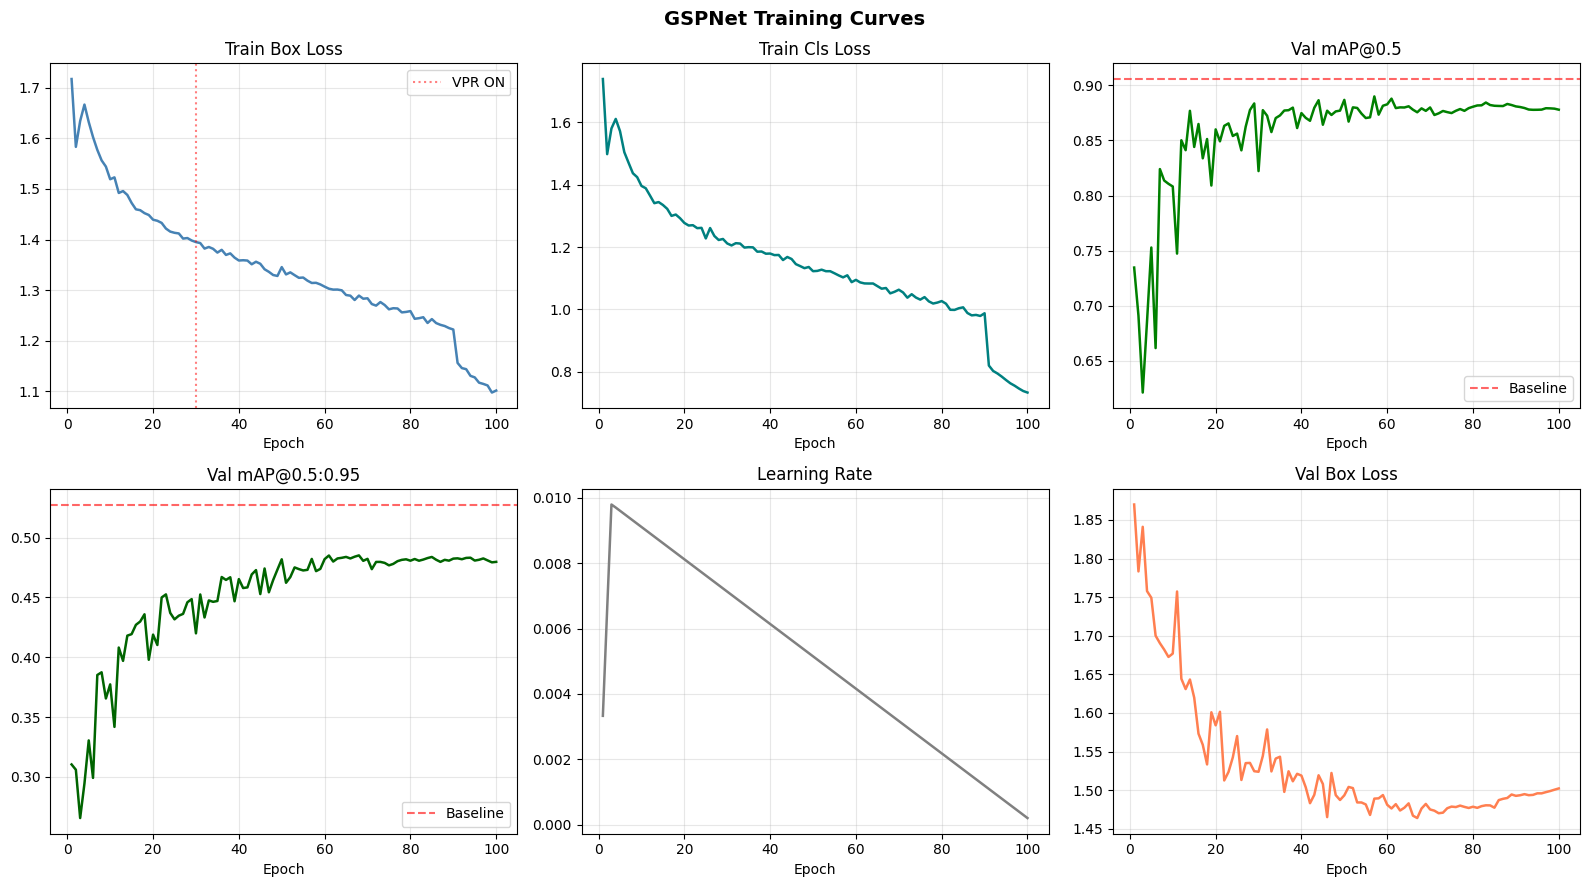

✓ Curves saved


In [15]:
# ── CELL 12: Training curves ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Read Ultralytics results CSV
results_csv = RUNS_DIR / 'gspnet' / 'results.csv'
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    pairs = [
        ('train/box_loss',       'Train Box Loss',      'steelblue'),
        ('train/cls_loss',       'Train Cls Loss',      'teal'),
        ('metrics/mAP50(B)',     'Val mAP@0.5',         'green'),
        ('metrics/mAP50-95(B)',  'Val mAP@0.5:0.95',    'darkgreen'),
        ('lr/pg0',               'Learning Rate',       'gray'),
        ('val/box_loss',         'Val Box Loss',        'coral'),
    ]
    for ax, (col, title, color) in zip(axes, pairs):
        if col in df.columns:
            ax.plot(df['epoch'], df[col], color=color, lw=1.8)
            if 'mAP' in col:
                ax.axhline(0.5277 if '95' in col else 0.9057,
                           color='red', ls='--', alpha=0.6, label='Baseline')
                ax.legend()
            ax.set(title=title, xlabel='Epoch'); ax.grid(alpha=0.3)

    # Mark VPR activation
    axes[0].axvline(30, color='red', ls=':', alpha=0.5, label='VPR ON')
    axes[0].legend()

    plt.suptitle('GSPNet Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RUNS_DIR / 'gspnet_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Curves saved')
else:
    print(f'results.csv not found at {results_csv}')
    print('Run Cell 9 (training) first.')

In [1]:
# ── CELL 13: Export for deployment ────────────────────────────────────────
from ultralytics import YOLO
import torch

model = YOLO(str(GSP_WEIGHTS))

# ── ONNX (cross-platform, recommended for API deployment) ─────────────────
try:
    onnx_path = model.export(format='onnx', dynamic=True, simplify=True)
    print(f'✓ ONNX          : {onnx_path}')
except Exception as e:
    print(f'✗ ONNX failed   : {e}')

# ── TorchScript (C++ runtime) ─────────────────────────────────────────────
try:
    ts_path = model.export(format='torchscript')
    print(f'✓ TorchScript   : {ts_path}')
except Exception as e:
    print(f'✗ TorchScript   : {e}')

# ── TensorRT FP16 (fastest GPU inference — requires TRT installed) ────────
if torch.cuda.is_available():
    try:
        trt_path = model.export(format='engine', half=True, device=0)
        print(f'✓ TensorRT FP16 : {trt_path}')
    except Exception as e:
        print(f'✗ TensorRT      : {e}  (TRT not installed on this Colab instance)')

# ── TFLite (mobile / edge CPU) ────────────────────────────────────────────
try:
    tfl_path = model.export(format='tflite')
    print(f'✓ TFLite        : {tfl_path}')
except Exception as e:
    print(f'✗ TFLite        : {e}')

print('\n── Inference example (after export) ─────────────────────')
print("""
from ultralytics import YOLO
model = YOLO('runs/gspnet/weights/best.pt')
results = model('your_gsv_image.jpg', conf=0.25, iou=0.45)
results[0].show()   # display with boxes
""")

NameError: name 'GSP_WEIGHTS' is not defined

In [ ]:
# ── CELL 14: Save all outputs to Google Drive ─────────────────────────────
import shutil

DRIVE_SAVE = Path('/content/drive/MyDrive/gspnet_runs')
DRIVE_SAVE.mkdir(parents=True, exist_ok=True)

to_save = [
    RUNS_DIR / 'gspnet_results.csv',
    RUNS_DIR / 'gspnet_curves.png',
    RUNS_DIR / 'aspect_ratio.png',
    RUNS_DIR / 'gspnet' / 'weights' / 'best.pt',
    RUNS_DIR / 'gspnet' / 'weights' / 'last.pt',
    RUNS_DIR / 'gspnet' / 'results.csv',
]

for src in to_save:
    src = Path(src)
    if src.exists():
        dst = DRIVE_SAVE / src.name
        shutil.copy2(src, dst)
        sz  = src.stat().st_size / 1e6
        print(f'  ✓ {src.name:<35} ({sz:.1f} MB) → {dst}')
    else:
        print(f'  ✗ Not found: {src.name}')

print(f'\n✓ Saved to: {DRIVE_SAVE}')
print('\n── Summary ───────────────────────────────────────────────')
print(f'  Baseline mAP@0.5     : 0.9057')
print(f'  Baseline mAP@0.5:0.95: 0.5277  ← primary target')
print(f'  VPR_TAU used         : {VPR_TAU}')
print(f'  GSPNet mAP@0.5       : {GSP_MAP50:.4f}')
print(f'  GSPNet mAP@0.5:0.95  : {GSP_MAP5095:.4f}  '
      f'(Δ = {GSP_MAP5095-0.5277:+.4f} pp)')